In [1]:
from pathlib import Path
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


Loaded: 201 GC(both), 552 GC(either), 6795 NGS, 1627 NS, 1536 contacts
Rendering 320° full brain (contacts)…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full_contacts.png

Rendering 0° posterior clipped (contacts)…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip_contacts.png

Computing annotation overlays (100µm slices)…
  done


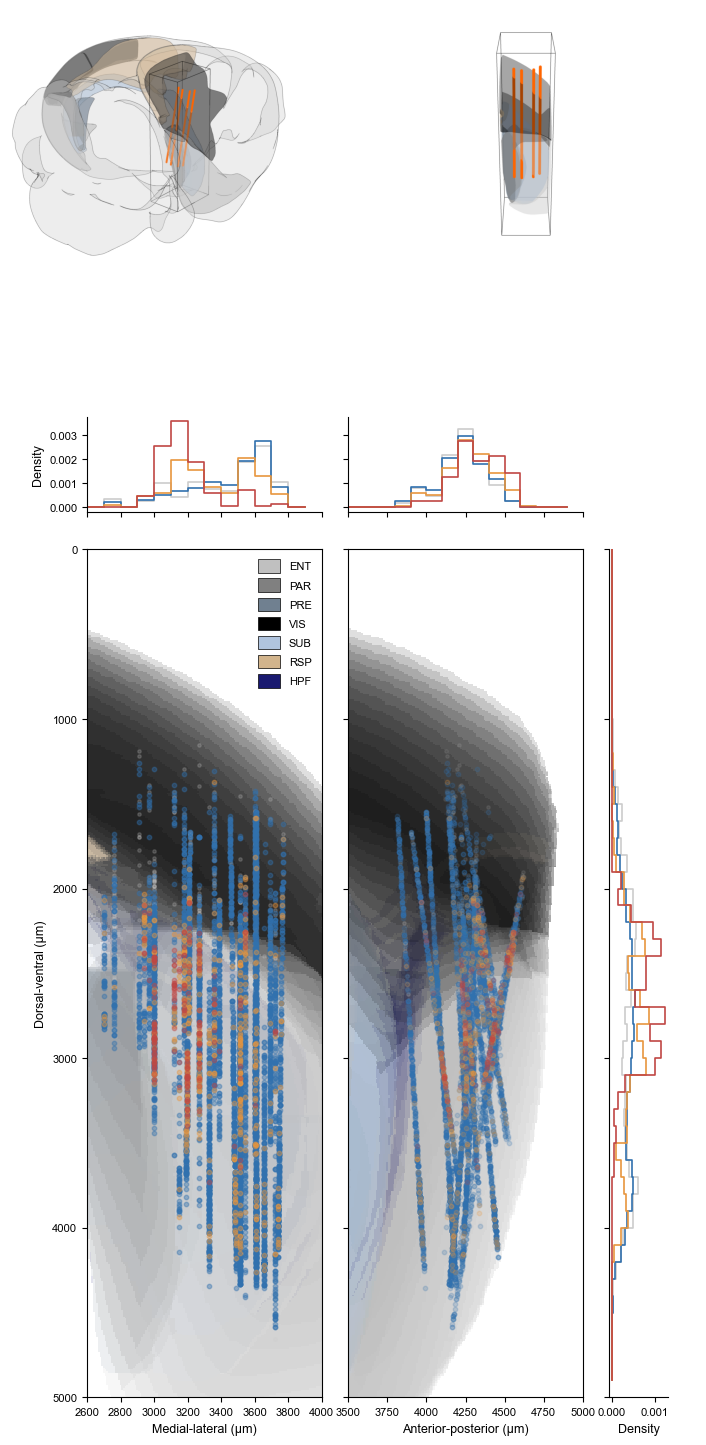

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_contacts_overview.pdf


In [2]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

_gc_all = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs    = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ns     = _df[~_df['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

_gc_either = _gc_all[_gc_all['classified_by'].isin(['OF1', 'OF2'])]
_gc_both   = _gc_all[~_gc_all['classified_by'].isin(['OF1', 'OF2'])]

_dc = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
_dc = _dc[_dc['mouse'] == 26]

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

contact_pts = _dc_to_ccf(_dc)

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_both_pts   = _df_to_ccf(_gc_both)   if len(_gc_both) > 0   else np.empty((0,3))
gc_either_pts = _df_to_ccf(_gc_either) if len(_gc_either) > 0 else np.empty((0,3))
ngs_pts       = _df_to_ccf(_ngs)
ns_pts        = _df_to_ccf(_ns)

ml_gc_both = -_gc_both['SC_x'].values;   ml_gc_either = -_gc_either['SC_x'].values
ml_ngs = -_ngs['SC_x'].values;           ml_ns = -_ns['SC_x'].values
dv_gc_both =  _gc_both['SC_y'].values;   dv_gc_either =  _gc_either['SC_y'].values
dv_ngs =  _ngs['SC_y'].values;           dv_ns =  _ns['SC_y'].values
ap_gc_both =  _gc_both['SC_z'].values;   ap_gc_either =  _gc_either['SC_z'].values
ap_ngs =  _ngs['SC_z'].values;           ap_ns =  _ns['SC_z'].values

print(f"Loaded: {len(_gc_both)} GC(both), {len(_gc_either)} GC(either), {len(_ngs)} NGS, {len(_ns)} NS, {len(_dc)} contacts")

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

contact_box   = contact_pts[in_bbox(contact_pts, bbox_min, bbox_max)]
gc_both_box   = gc_both_pts[in_bbox(gc_both_pts, bbox_min, bbox_max)]     if len(gc_both_pts) > 0   else np.empty((0,3))
gc_either_box = gc_either_pts[in_bbox(gc_either_pts, bbox_min, bbox_max)] if len(gc_either_pts) > 0 else np.empty((0,3))
ngs_box       = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]
ns_box        = ns_pts[in_bbox(ns_pts, bbox_min, bbox_max)]

STRUCT_REGIONS = [
    ('ENT', 'silver',         0.40),
    ('PAR', 'grey',           0.50),
    ('PRE', 'slategrey',      0.50),
    ('VIS', 'black',          0.35),
    ('SUB', 'lightsteelblue', 0.40),
    ('RSP', 'tan',            0.35),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

COL_BOTH    = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_EITHER = '#e8963e'
COL_NGS     = '#3171ae'
COL_NS      = '#cccccc'
COL_CONTACT = '#ff6500'

def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(contact_pts, name='contacts', colors=COL_CONTACT, radius=40, alpha=0.6))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain (contacts)…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full_contacts'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full_contacts.png'))

def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(contact_box) > 0:
        scene.add(Points(contact_box, name='contacts', colors=COL_CONTACT, radius=40, alpha=0.6))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped (contacts)…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip_contacts'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip_contacts.png'))

print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if 'ENT' in acr:      numeric[m] = 1
        elif 'PAR' in acr:    numeric[m] = 2
        elif 'PRE' in acr:    numeric[m] = 3
        elif 'VIS' in acr:    numeric[m] = 4
        elif 'SUB' in acr:    numeric[m] = 5
        elif 'RSP' in acr:    numeric[m] = 6
        elif 'HPF' in acr:    numeric[m] = 7
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for name in ['silver', 'grey', 'slategrey', 'black', 'lightsteelblue', 'tan', 'midnightblue']:
    r, g, b, _ = to_rgba(name)
    cmap_list.append((r, g, b, 0.125))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), region_cmap.N)

DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 7
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 5.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.3 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.01, right=0.99, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ml_dv.scatter(ml_ns, dv_ns, color=COL_NS, alpha=0.2, s=6, zorder=1)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color=COL_NGS, alpha=0.4, s=10, zorder=2)
ax_ml_dv.scatter(ml_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.4, s=10, zorder=3)
ax_ml_dv.scatter(ml_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.4, s=10, zorder=4)
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

region_legend = [
    Patch(facecolor='silver', edgecolor='black', lw=0.5, label='ENT'),
    Patch(facecolor='grey', edgecolor='black', lw=0.5, label='PAR'),
    Patch(facecolor='slategrey', edgecolor='black', lw=0.5, label='PRE'),
    Patch(facecolor='black', edgecolor='black', lw=0.5, label='VIS'),
    Patch(facecolor='lightsteelblue', edgecolor='black', lw=0.5, label='SUB'),
    Patch(facecolor='tan', edgecolor='black', lw=0.5, label='RSP'),
    Patch(facecolor='midnightblue', edgecolor='black', lw=0.5, label='HPF'),
]
ax_ml_dv.legend(handles=region_legend, fontsize=8, frameon=False, loc='upper right',
                handlelength=2, handleheight=1.5, labelspacing=0.5)

for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ap_dv.scatter(ap_ns, dv_ns, color=COL_NS, alpha=0.1, s=6, zorder=1)
ax_ap_dv.scatter(ap_ngs, dv_ngs, color=COL_NGS, alpha=0.2, s=10, zorder=2)
ax_ap_dv.scatter(ap_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.2, s=10, zorder=3)
ax_ap_dv.scatter(ap_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.2, s=10, zorder=4)
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 100)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ns, ml_bins, density=True)[0],
             where='post', color=COL_NS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_either, ml_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_both, ml_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 100)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ns, ap_bins, density=True)[0],
             where='post', color=COL_NS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_either, ap_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_both, ap_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 100)
ax_dv_h.step(np.histogram(dv_ns, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NS, lw=1.2)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NGS, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_either, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_EITHER, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_both, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_BOTH, lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_contacts_overview.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=1000)
plt.show()
print(f"Saved → {out_path}")


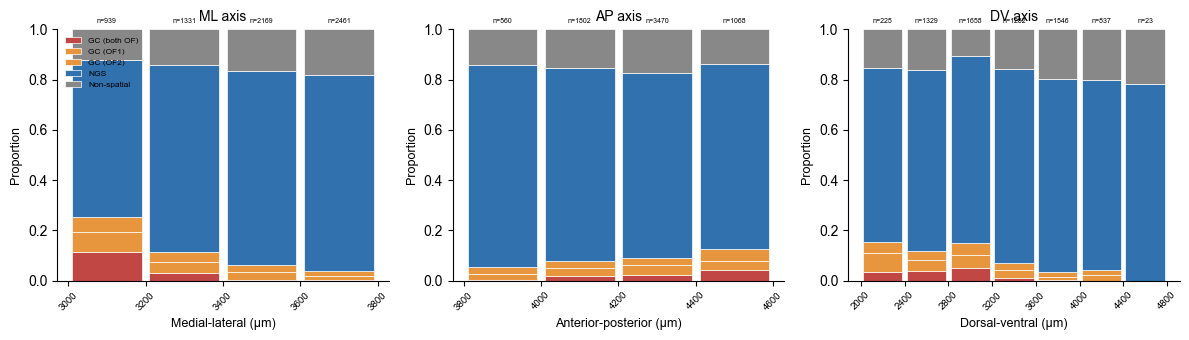

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()
_cc['ml'] = _cc['SC_x'].abs()
_cc['dv'] = _cc['SC_y']
_cc['ap'] = _cc['SC_z']

# Assign category
cats = []
for _, row in _cc.iterrows():
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        cats.append(cb if cb in ('both', 'OF1', 'OF2') else 'OF1')
    elif row['cell_type'] == 'NG':
        cats.append('NGS')
    else:
        cats.append('Other')
_cc['_cat'] = cats

cat_order = ['both', 'OF1', 'OF2', 'NGS', 'Other']
cat_colors = {'both': '#c04744', 'OF1': '#e8963e', 'OF2': '#e8963e', 'NGS': '#3171ae', 'Other': '#888888'}
cat_labels = {'both': 'GC (both OF)', 'OF1': 'GC (OF1)', 'OF2': 'GC (OF2)', 'NGS': 'NGS', 'Other': 'Non-spatial'}

ml_bins = np.arange(3000, 3901, 200)
ap_bins = np.arange(3800, 4701, 200)
dv_bins = np.arange(2000, 4801, 400)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for col_idx, (pos_col, bins, xlabel, axis_name) in enumerate([
    ('ml', ml_bins, 'Medial-lateral (µm)', 'ML'),
    ('ap', ap_bins, 'Anterior-posterior (µm)', 'AP'),
    ('dv', dv_bins, 'Dorsal-ventral (µm)', 'DV'),
]):
    ax = axes[col_idx]
    centres = (bins[:-1] + bins[1:]) / 2
    bar_w = (bins[1] - bins[0]) * 0.9

    _cc['_bin'] = pd.cut(_cc[pos_col], bins=bins, right=False)

    counts = _cc.groupby(['_bin', '_cat']).size().unstack(fill_value=0)
    for c in cat_order:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[cat_order]
    proportions = counts.div(counts.sum(axis=1), axis=0)

    bottom = np.zeros(len(proportions))
    for cat in cat_order:
        vals = proportions[cat].values
        ax.bar(centres, vals, width=bar_w, bottom=bottom,
               color=cat_colors[cat], label=cat_labels[cat],
               edgecolor='white', lw=0.5)
        bottom += vals

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_title(f'{axis_name} axis', fontsize=10)
    ax.set_xticks(bins)
    ax.set_xticklabels([f'{int(e)}' for e in bins], fontsize=7, rotation=45)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

    for j, (centre, total) in enumerate(zip(centres, counts.sum(axis=1).values)):
        ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=5)

    if col_idx == 0:
        ax.legend(fontsize=6, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/entm_cell_type_proportions_3axes.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

_cc.drop(columns=['_cat', '_bin'], inplace=True)


6900 ENTm cells, 7 mice
Layer counts: {'L1': 760, 'L2': 1463, 'L3': 2445, 'L5': 1707, 'L6': 525}

SI model: quad (AIC: {'main': np.float64(-2078.6548576471687), 'inter': np.float64(-2119.0819957965214), 'quad': np.float64(-2231.104833868827)})
          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  si       
No. Observations:  6900     Method:              REML     
No. Groups:        7        Scale:               0.0409   
Min. group size:   260      Log-Likelihood:      1127.5524
Max. group size:   2152     Converged:           Yes      
Mean group size:   985.7                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.098    0.011  8.979 0.000  0.077  0.120
ml_z            -0.019    0.006 -3.309 0.001 -0.030 -0.008
dv_z            -0.004    0.005 -0.818 0.413 -0.015  0.006


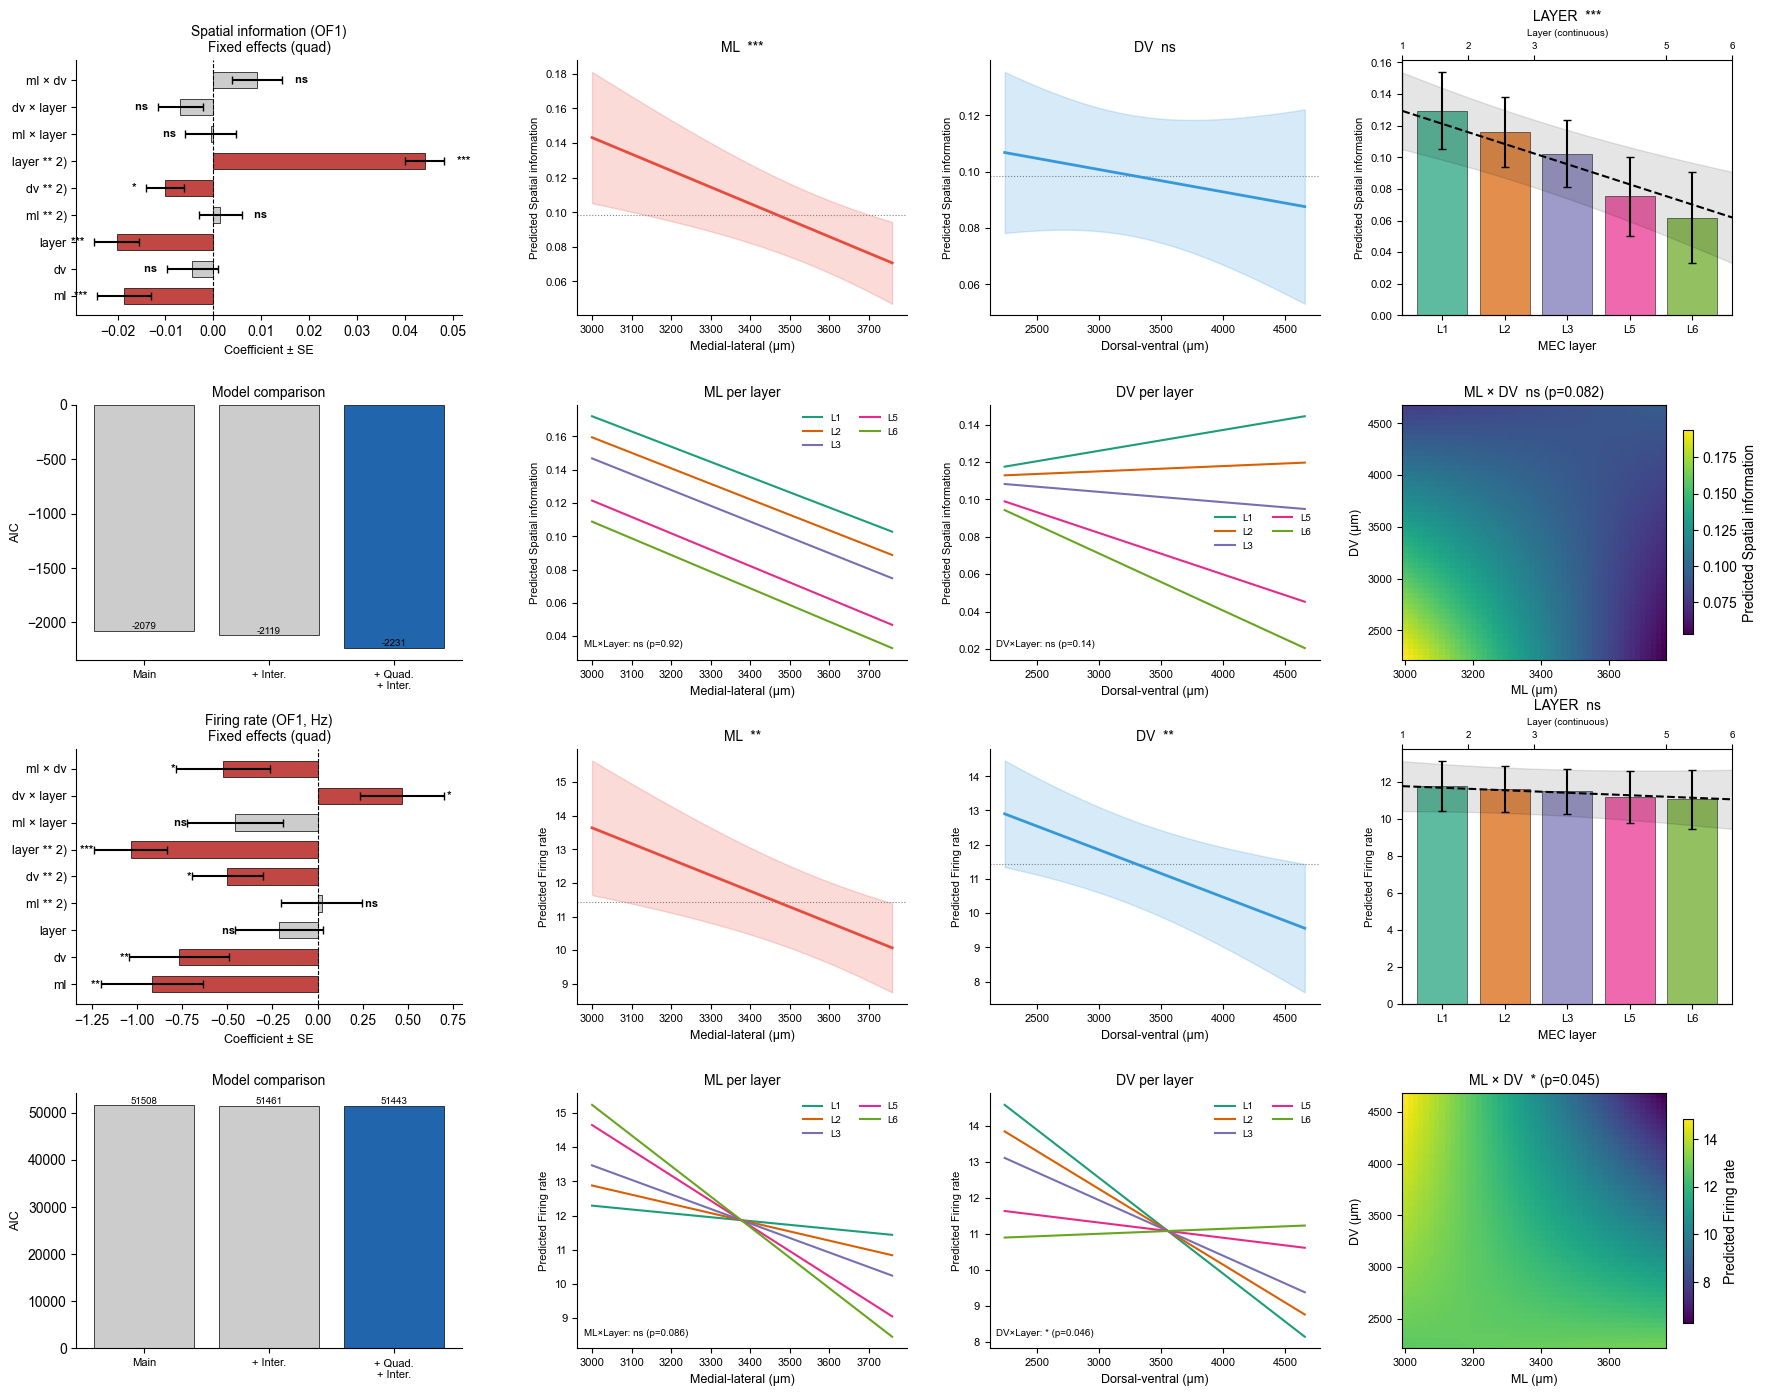

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

# ── Load and prepare data ────────────────────────────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

df = _cc.copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['fr'] = df['firing_rate_OF1']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

df['layer_num'] = df['brain_region'].apply(get_layer_num)
df = df[df['layer_num'].notna()].copy()
df['layer_label'] = 'L' + df['layer_num'].astype(int).astype(str)

df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()
df['layer_z'] = (df['layer_num'] - df['layer_num'].mean()) / df['layer_num'].std()

print(f"{len(df)} ENTm cells, {df['_mouse'].nunique()} mice")
print(f"Layer counts: {df['layer_label'].value_counts().sort_index().to_dict()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    if real_col == 'layer':
        return z_vals * df['layer_num'].std() + df['layer_num'].mean()
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def layer_num_to_z(ln):
    return (ln - df['layer_num'].mean()) / df['layer_num'].std()

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)

    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)

    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)

    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
layer_weights = np.array([len(df[df['layer_num'] == ln]) for ln in layer_nums], dtype=float)
layer_weights /= layer_weights.sum()

n_pts = 200

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', '#e74c3c'),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', '#3498db'),
    ('layer_z', 'layer', 'MEC layer', '#2ca02c'),
]

# ── Fit models ───────────────────────────────────────────────────────────────
df_si = df[df['si'].notna()].copy()
best_si, best_si_name, aic_si = fit_and_select('si', df_si)
df_si['_fitted'] = best_si.fittedvalues
print(f"\nSI model: {best_si_name} (AIC: {aic_si})")
print(best_si.summary())

df_fr = df[df['fr'].notna()].copy()
best_fr, best_fr_name, aic_fr = fit_and_select('fr', df_fr)
df_fr['_fitted'] = best_fr.fittedvalues
print(f"\nFR model: {best_fr_name} (AIC: {aic_fr})")
print(best_fr.summary())

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE: 4 rows × 2 columns (left: coefficients/AIC, right: 3 partial effects)
# Rows 0-1: Spatial information
# Rows 2-3: Firing rate
# ══════════════════════════════════════════════════════════════════════════════

measures = [
    ('Spatial information (OF1)', 'si', df_si, best_si, best_si_name, aic_si),
    ('Firing rate (OF1, Hz)', 'fr', df_fr, best_fr, best_fr_name, aic_fr),
]

fig = plt.figure(figsize=(18, 14))
outer = gridspec.GridSpec(4, 2, figure=fig, width_ratios=[1, 3], wspace=0.15, hspace=0.35,
                          top=0.96, bottom=0.04, left=0.05, right=0.97)

for m_idx, (measure_label, dv_col, df_m, best_m, best_m_name, aic_m) in enumerate(measures):
    row_coef = m_idx * 2
    row_partial = m_idx * 2
    row_inter = m_idx * 2 + 1

    # ── Left: Coefficients ───────────────────────────────────────────────────
    ax_coef = fig.add_subplot(outer[row_coef, 0])

    fe = best_m.fe_params.drop('Intercept')
    se_coef = best_m.bse.reindex(fe.index)
    pvals_fe = best_m.pvalues.reindex(fe.index)
    display_names = [n.replace('_z', '').replace('I(', '').replace('**2)', '²').replace(':', ' × ')
                     for n in fe.index]
    colors_coef = ['#c04744' if p < 0.05 else '#cccccc' for p in pvals_fe]
    y_pos = np.arange(len(fe))

    ax_coef.barh(y_pos, fe.values, xerr=se_coef.values, color=colors_coef,
                 edgecolor='black', lw=0.5, capsize=3, height=0.6)
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(display_names, fontsize=9)
    ax_coef.axvline(0, color='black', lw=0.8, ls='--')
    ax_coef.set_xlabel('Coefficient ± SE', fontsize=9)
    ax_coef.set_title(f'{measure_label}\nFixed effects ({best_m_name})', fontsize=10)
    ax_coef.spines[['top', 'right']].set_visible(False)

    for i, (coef, p) in enumerate(zip(fe.values, pvals_fe)):
        stars = pval_to_stars(p)
        x_off = se_coef.values[i] + 0.002 if coef >= 0 else -se_coef.values[i] - 0.002
        ax_coef.text(coef + x_off, i, f' {stars}', ha='left' if coef >= 0 else 'right',
                     va='center', fontsize=8, fontweight='bold')

    # ── Left: AIC ────────────────────────────────────────────────────────────
    ax_aic = fig.add_subplot(outer[row_inter, 0])
    names_disp = ['Main', '+ Inter.', '+ Quad.\n+ Inter.']
    aic_list = [aic_m['main'], aic_m['inter'], aic_m['quad']]
    aic_col = ['#2166ac' if n == best_m_name else '#cccccc' for n in ['main', 'inter', 'quad']]
    ax_aic.bar(range(3), aic_list, color=aic_col, edgecolor='black', lw=0.5)
    ax_aic.set_xticks(range(3))
    ax_aic.set_xticklabels(names_disp, fontsize=8)
    ax_aic.set_ylabel('AIC', fontsize=9)
    ax_aic.set_title('Model comparison', fontsize=10)
    ax_aic.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(aic_list):
        ax_aic.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    # ── Right row 0: Partial effects with CI ─────────────────────────────────
    right_partial = outer[row_partial, 1].subgridspec(1, 3, wspace=0.25)

    for col_idx, (z_col, real_col, xlabel, color) in enumerate(all_axes_info):
        ax = fig.add_subplot(right_partial[0, col_idx])
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        if z_col == 'layer_z':
            params_list = list(best_m.fe_params.keys())
            cov_mat = best_m.cov_params().loc[params_list, params_list].values
            lz_vals = np.array([layer_num_to_z(ln) for ln in layer_nums])
            pred_vals, se_vals = [], []
            for lz in lz_vals:
                d = {c: 0 for c in hold_others}; d[z_col] = lz
                pred_vals.append(predict_simple(best_m, d))
                x_row = get_design_row(best_m, d)
                se_vals.append(np.sqrt(x_row @ cov_mat @ x_row))
            pred_vals = np.array(pred_vals)
            se_vals = np.array(se_vals)

            ax.bar(np.arange(len(layer_nums)), pred_vals, yerr=1.96*se_vals, capsize=3,
                   color=[layer_colors[f'L{ln}'] for ln in layer_nums], edgecolor='black',
                   lw=0.5, alpha=0.7, zorder=3)

            z_cont = np.linspace(df_m['layer_z'].min(), df_m['layer_z'].max(), n_pts)
            real_cont = z_to_real(z_cont, 'layer_z')
            pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)
            ax2 = ax.twiny()
            ax2.plot(real_cont, pred_cont, color='black', lw=1.5, ls='--', zorder=5)
            ax2.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                             color='black', alpha=0.1, zorder=4)
            ax2.set_xlim(real_cont[0], real_cont[-1])
            ax2.set_xticks([1, 2, 3, 5, 6])
            ax2.tick_params(labelsize=7)
            ax2.set_xlabel('Layer (continuous)', fontsize=7)

            ax.set_xticks(np.arange(len(layer_nums)))
            ax.set_xticklabels(layer_labels, fontsize=9)
        else:
            z_vals = np.linspace(df_m[z_col].min(), df_m[z_col].max(), n_pts)
            real_vals = z_to_real(z_vals, z_col)
            pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)
            ax.plot(real_vals, pred, color=color, lw=2, zorder=4)
            ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                            color=color, alpha=0.2, zorder=3)
            ax.axhline(best_m.fe_params['Intercept'], color='grey', ls=':', lw=0.8)

        p_main = best_m.pvalues.get(z_col, np.nan)
        ax.set_title(f'{real_col.upper()}  {pval_to_stars(p_main)}', fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(f'Predicted {measure_label.split("(")[0].strip()}', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    # ── Right row 1: Per-layer ML/DV effects + heatmap ───────────────────────
    right_inter = outer[row_inter, 1].subgridspec(1, 3, wspace=0.25)

    ax_ml_l = fig.add_subplot(right_inter[0, 0])
    z_ml = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_pts)
    r_ml = z_to_real(z_ml, 'ml_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': z, 'dv_z': 0, 'layer_z': lz}) for z in z_ml]
        ax_ml_l.plot(r_ml, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_ml_l.set_xlabel('Medial-lateral (µm)', fontsize=9)
    ax_ml_l.set_ylabel(f'Predicted {measure_label.split("(")[0].strip()}', fontsize=8)
    ax_ml_l.set_title('ML per layer', fontsize=10)
    ax_ml_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_ml_l.spines[['top', 'right']].set_visible(False)
    ax_ml_l.tick_params(labelsize=8)
    if 'ml_z:layer_z' in best_m.pvalues:
        p_mli = best_m.pvalues['ml_z:layer_z']
        ax_ml_l.annotate(f'ML×Layer: {pval_to_stars(p_mli)} (p={p_mli:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_dv_l = fig.add_subplot(right_inter[0, 1])
    z_dv = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_pts)
    r_dv = z_to_real(z_dv, 'dv_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': 0, 'dv_z': z, 'layer_z': lz}) for z in z_dv]
        ax_dv_l.plot(r_dv, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_dv_l.set_xlabel('Dorsal-ventral (µm)', fontsize=9)
    ax_dv_l.set_ylabel(f'Predicted {measure_label.split("(")[0].strip()}', fontsize=8)
    ax_dv_l.set_title('DV per layer', fontsize=10)
    ax_dv_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_dv_l.spines[['top', 'right']].set_visible(False)
    ax_dv_l.tick_params(labelsize=8)
    if 'dv_z:layer_z' in best_m.pvalues:
        p_dvl = best_m.pvalues['dv_z:layer_z']
        ax_dv_l.annotate(f'DV×Layer: {pval_to_stars(p_dvl)} (p={p_dvl:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_hm = fig.add_subplot(right_inter[0, 2])
    n_grid = 50
    ml_zr = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_grid)
    dv_zr = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_grid)
    MZ, DZ = np.meshgrid(ml_zr, dv_zr)
    pg = np.zeros_like(MZ)
    for ln, w in zip(layer_nums, layer_weights):
        lz = layer_num_to_z(ln)
        for i in range(n_grid):
            for j in range(n_grid):
                pg[i, j] += w * predict_simple(best_m, {'ml_z': MZ[i,j], 'dv_z': DZ[i,j], 'layer_z': lz})
    ml_r = z_to_real(ml_zr, 'ml_z')
    dv_r = z_to_real(dv_zr, 'dv_z')
    im = ax_hm.pcolormesh(ml_r, dv_r, pg, cmap='viridis', shading='auto', rasterized=True)
    plt.colorbar(im, ax=ax_hm, shrink=0.8,
                 label=f'Predicted {measure_label.split("(")[0].strip()}')
    if 'ml_z:dv_z' in best_m.pvalues:
        p_mlvd = best_m.pvalues['ml_z:dv_z']
        ax_hm.set_title(f'ML × DV  {pval_to_stars(p_mlvd)} (p={p_mlvd:.2g})', fontsize=10)
    else:
        ax_hm.set_title('ML × DV', fontsize=10)
    ax_hm.set_xlabel('ML (µm)', fontsize=9)
    ax_hm.set_ylabel('DV (µm)', fontsize=9)
    ax_hm.tick_params(labelsize=8)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/si_fr_layer_glmm.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


In [5]:
device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])

Example cell: M25D24 c152, GS=1.44, both
D24: 10 GC + 14 NGS = 24
D19: 6 GC + 18 NGS = 24
D22: 3 GC + 21 NGS = 24
D23: 1 GC + 23 NGS = 24


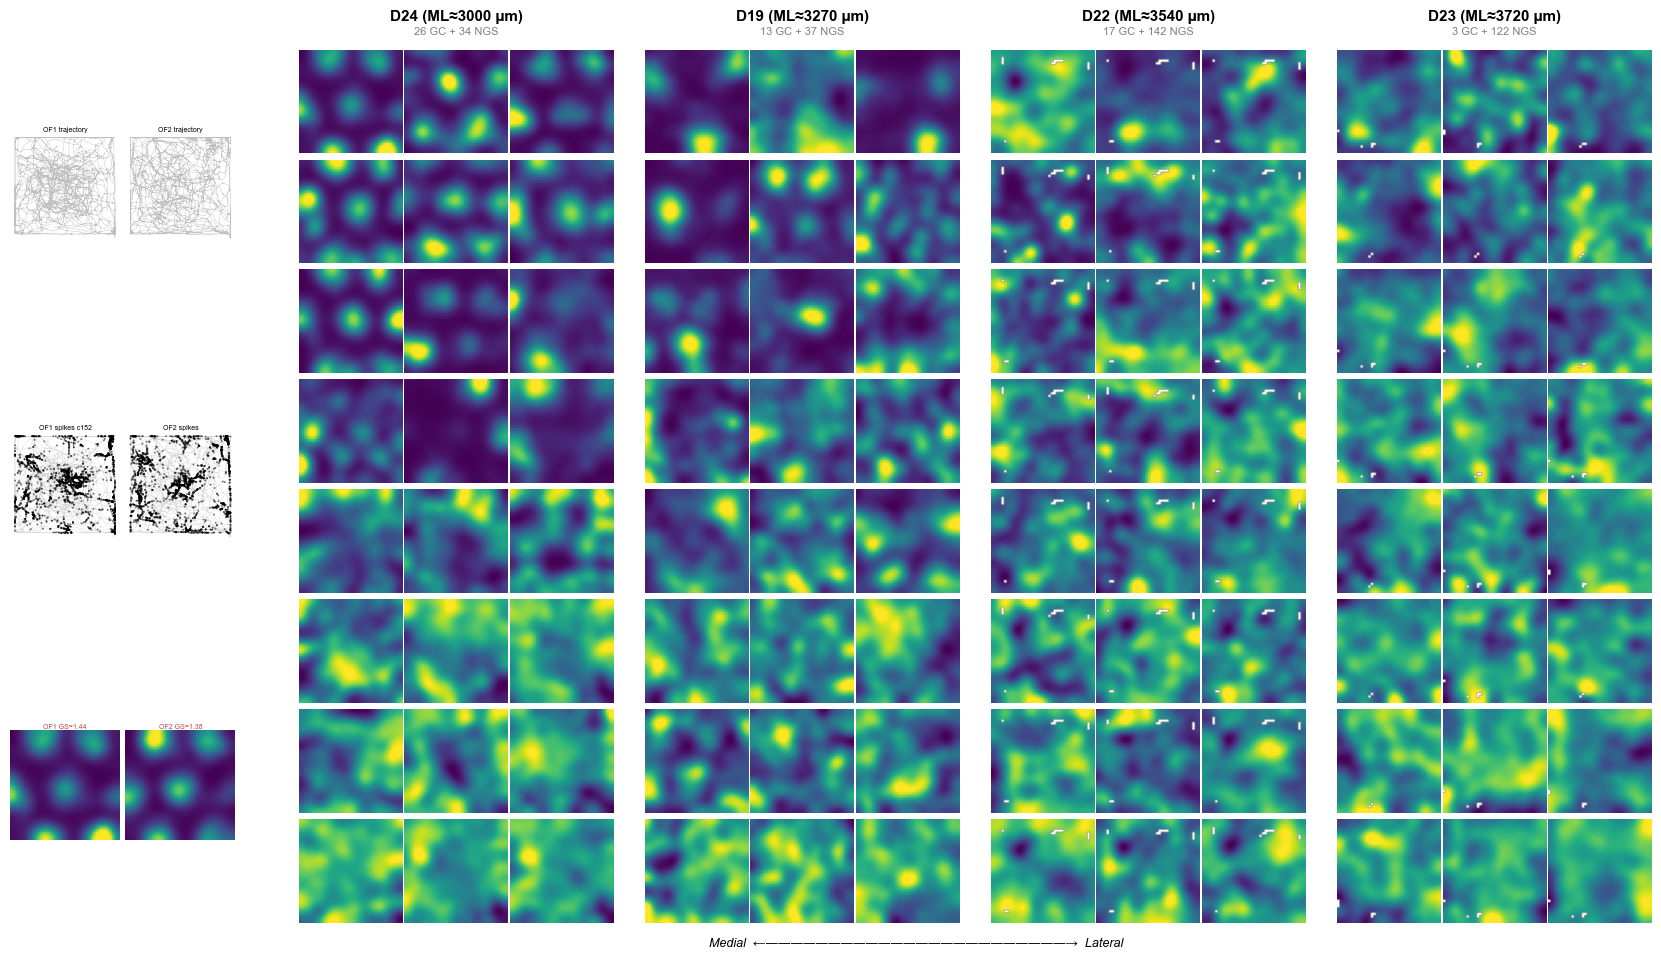

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
)

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'
SPEED_THRESHOLD = 50

def _load_beh_clusters(mouse, day, session, source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"
    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)
    return beh, clusters

def _get_speed_mask(beh, threshold=SPEED_THRESHOLD):
    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    times = beh['P_x'].times()
    dt = np.diff(times)
    dx = np.diff(px)
    dy = np.diff(py)
    speed = np.sqrt(dx**2 + dy**2) / dt
    speed_full = np.concatenate([[0], speed])
    return speed_full < threshold

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)
    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))
    ax.imshow(tc, cmap='viridis')
    ax.axis('off')

def plot_trajectory(ax, mouse, day, session, source_path=SOURCE_PATH):
    beh, _ = _load_beh_clusters(mouse, day, session, source_path)
    px = np.array(beh['P_x']).copy()
    py = np.array(beh['P_y']).copy()
    mask = _get_speed_mask(beh)
    px[~mask] = np.nan
    py[~mask] = np.nan
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.5)
    ax.set_aspect('equal')
    ax.axis('off')

def plot_spike_positions(ax, cluster_id, mouse, day, session, source_path=SOURCE_PATH, color='black'):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    px = np.array(beh['P_x']).copy()
    py = np.array(beh['P_y']).copy()
    pos_times = beh['P_x'].times()
    mask = _get_speed_mask(beh)
    px_traj = px.copy()
    py_traj = py.copy()
    px_traj[~mask] = np.nan
    py_traj[~mask] = np.nan
    ax.plot(px_traj, py_traj, color='grey', lw=0.3, alpha=0.3)
    spike_times = clusters[cluster_id].times()
    spike_idx = np.searchsorted(pos_times, spike_times)
    spike_idx = spike_idx[spike_idx < len(px)]
    spike_mask = mask[spike_idx]
    spike_idx = spike_idx[spike_mask]
    ax.scatter(px[spike_idx], py[spike_idx], c=color, s=2, alpha=0.5, zorder=3, edgecolors='none')
    ax.set_aspect('equal')
    ax.axis('off')

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

mouse = 25
sessions = [24, 19, 22, 23]
N_TOTAL = 24
N_COLS_PER_SESSION = 3
N_ROWS = N_TOTAL // N_COLS_PER_SESSION

example_day = 24
example_gc = _df[(_df['mouse'] == mouse) & (_df['day'] == example_day) & (_df['cell_type'] == 'GC')]
example_gc = example_gc.sort_values('grid_score_best', ascending=False)
example_cid = int(example_gc.iloc[0]['cluster_id'])
example_cb = example_gc.iloc[0]['classified_by']
example_gs = example_gc.iloc[0]['grid_score_best']
print(f"Example cell: M{mouse}D{example_day} c{example_cid}, GS={example_gs:.2f}, {example_cb}")

np.random.seed(42)

session_cells = {}
session_counts = {}

for day in sessions:
    sub = _df[(_df['mouse'] == mouse) & (_df['day'] == day)]
    gc = sub[sub['cell_type'] == 'GC'].copy()
    gc['ml'] = gc['SC_x'].abs()
    ngs = sub[sub['cell_type'] == 'NG'].copy()
    ngs['ml'] = ngs['SC_x'].abs()
    other = sub[sub['cell_type'] == 'Other']

    session_counts[day] = {
        'GC_both': len(gc[gc['classified_by'] == 'both']),
        'GC_either': len(gc[gc['classified_by'].isin(['OF1', 'OF2'])]),
        'NGS': len(ngs),
        'Other': len(other),
        'Total': len(sub),
    }

    total = len(gc) + len(ngs)
    n_gc = round((len(gc) / total) * N_TOTAL) if total > 0 else 0
    n_gc = max(n_gc, min(1, len(gc)))
    n_ngs = N_TOTAL - n_gc

    gc = gc.sort_values('grid_score_best', ascending=False)
    if len(gc) > n_gc:
        gc = gc.head(n_gc)

    ngs_sorted_dv = ngs.sort_values('SC_y')
    if len(ngs_sorted_dv) > n_ngs:
        idx = np.linspace(0, len(ngs_sorted_dv) - 1, n_ngs).astype(int)
        ngs = ngs_sorted_dv.iloc[idx]
    else:
        ngs = ngs_sorted_dv
    ngs = ngs.sort_values('spatial_information_score_best', ascending=False)

    gc = gc.copy()
    ngs = ngs.copy()
    gc['_type'] = 'GC'
    ngs['_type'] = 'NGS'
    combined = pd.concat([gc, ngs]).reset_index(drop=True)
    session_cells[day] = combined
    print(f'D{day}: {len(gc)} GC + {len(ngs)} NGS = {len(combined)}')

n_example_cols = 2
total_right_cols = len(sessions) * N_COLS_PER_SESSION

fig = plt.figure(figsize=(n_example_cols * 1.2 + 0.3 + total_right_cols * 1.2, N_ROWS * 1.2))
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08,
                          width_ratios=[n_example_cols, total_right_cols],
                          top=0.94, bottom=0.03, left=0.02, right=0.98)

left_gs = outer[0, 0].subgridspec(3, 2, wspace=0.05, hspace=0.08)

ax_traj_of1 = fig.add_subplot(left_gs[0, 0])
ax_traj_of2 = fig.add_subplot(left_gs[0, 1])
plot_trajectory(ax_traj_of1, mouse, example_day, 'OF1')
ax_traj_of1.set_title('OF1 trajectory', fontsize=5, pad=1)
plot_trajectory(ax_traj_of2, mouse, example_day, 'OF2')
ax_traj_of2.set_title('OF2 trajectory', fontsize=5, pad=1)

ax_spk_of1 = fig.add_subplot(left_gs[1, 0])
ax_spk_of2 = fig.add_subplot(left_gs[1, 1])
plot_spike_positions(ax_spk_of1, example_cid, mouse, example_day, 'OF1', color='black')
ax_spk_of1.set_title(f'OF1 spikes c{example_cid}', fontsize=5, pad=1, color='black')
plot_spike_positions(ax_spk_of2, example_cid, mouse, example_day, 'OF2', color='black')
ax_spk_of2.set_title(f'OF2 spikes', fontsize=5, pad=1, color='black')

ax_rm_of1 = fig.add_subplot(left_gs[2, 0])
ax_rm_of2 = fig.add_subplot(left_gs[2, 1])
plot_of_rate_map(ax_rm_of1, example_cid, mouse, example_day, _df, session='OF1')
ax_rm_of1.set_title(f'OF1 GS={example_gs:.2f}', fontsize=5, pad=1, color=COL_BOTH)
plot_of_rate_map(ax_rm_of2, example_cid, mouse, example_day, _df, session='OF2')
gs_of2 = example_gc.iloc[0].get('grid_score_of2', np.nan)
ax_rm_of2.set_title(f'OF2 GS={gs_of2:.2f}', fontsize=5, pad=1, color=COL_BOTH)

right_gs = outer[0, 1].subgridspec(1, len(sessions), wspace=0.1)

for s_idx, day in enumerate(sessions):
    cells = session_cells[day]
    ml_val = cells['ml'].iloc[0] if len(cells) > 0 else 0
    counts = session_counts[day]

    inner = right_gs[0, s_idx].subgridspec(N_ROWS, N_COLS_PER_SESSION, wspace=0.02, hspace=0.06)

    mid_x = (right_gs[0, s_idx].get_position(fig).x0 + right_gs[0, s_idx].get_position(fig).x1) / 2
    fig.text(mid_x, 0.97, f'D{day} (ML≈{ml_val:.0f} µm)',
             ha='center', fontsize=11, weight='bold')
    fig.text(mid_x, 0.955, f'{counts["GC_both"]+counts["GC_either"]} GC + {counts["NGS"]} NGS',
             ha='center', fontsize=8, color='grey')

    for idx in range(min(len(cells), N_TOTAL)):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])

        ex = cells.iloc[idx]
        cid = int(ex.cluster_id)
        cell_type = ex['_type']

        try:
            plot_of_rate_map(ax, cid, mouse, day, _df, session='OF1')
        except Exception as e:
            ax.text(0.5, 0.5, '—', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.axis('off')
            print(f"  Failed M{mouse}D{day} c{cid}: {e}")

    for idx in range(len(cells), N_ROWS * N_COLS_PER_SESSION):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])
        ax.axis('off')

fig.text(0.55, 0.005, 'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=9, style='italic')

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/M25_proportional_gc_ngs_with_example.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


ENTm cells: 6900
  GC (both): 159
  GC (either): 457
  NGS: 5177
  GC (both) Spatial information (bits / spike): main (n=159)
  GC (both) Firing rate (Hz): inter (n=159)
  GC (both) Spatial stability (Pearson R): main (n=159)
  GC (either) Spatial information (bits / spike): main (n=457)
  GC (either) Firing rate (Hz): quad (n=457)
  GC (either) Spatial stability (Pearson R): main (n=452)
  NGS Spatial information (bits / spike): quad (n=5177)
  NGS Firing rate (Hz): quad (n=5177)
  NGS Spatial stability (Pearson R): main (n=4987)


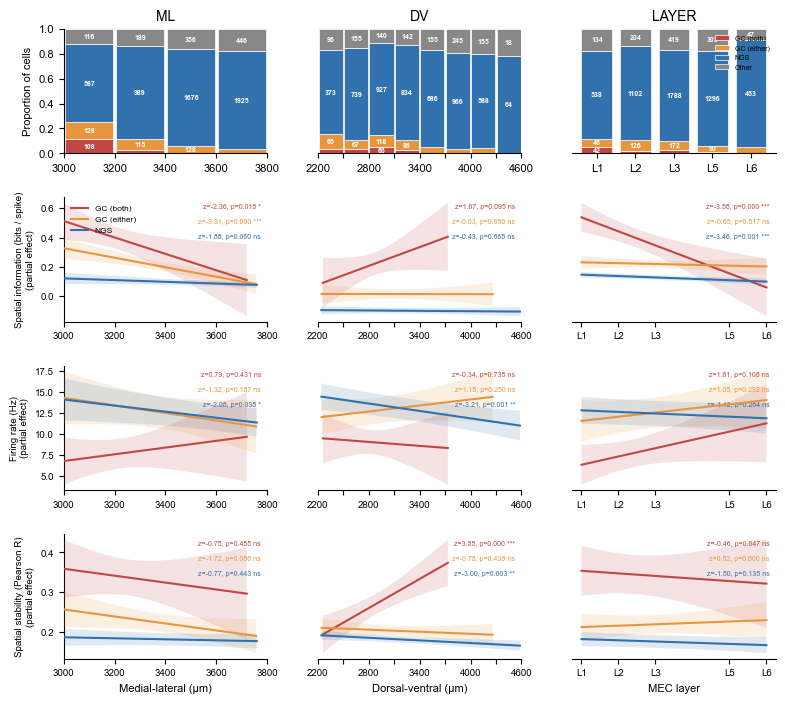

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_NGS       = '#3171ae'
COL_GC_BOTH   = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_OTHER     = '#888888'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

stab_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')
_cc = _cc.merge(stab_df[['mouse', 'day', 'cluster_id', 'stability']],
                on=['mouse', 'day', 'cluster_id'], how='left')

def get_cell_group(row):
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        return 'GC_both' if cb == 'both' else 'GC_either'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

_cc['_group'] = _cc.apply(get_cell_group, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

_cc['layer_num'] = _cc['brain_region'].apply(get_layer_num)
_cc = _cc[_cc['layer_num'].notna()].copy()

# Prepare subsets
cell_groups = [
    ('GC (both)',   'GC_both',   COL_GC_BOTH),
    ('GC (either)', 'GC_either', COL_GC_EITHER),
    ('NGS',         'NGS',       COL_NGS),
]

def prepare_df(cc_sub):
    d = cc_sub.copy()
    d['ml'] = d['SC_x'].abs()
    d['dv'] = d['SC_y']
    d['si'] = d['spatial_information_score_of1']
    d['fr'] = d['firing_rate_OF1']
    d['stab'] = d['stability']
    d['_mouse'] = d['mouse'].astype(int)
    d['_session'] = d['_mouse'].astype(str) + '_' + d['day'].astype(int).astype(str)
    d['ml_z'] = (d['ml'] - d['ml'].mean()) / d['ml'].std()
    d['dv_z'] = (d['dv'] - d['dv'].mean()) / d['dv'].std()
    d['layer_z'] = (d['layer_num'] - d['layer_num'].mean()) / d['layer_num'].std()
    return d

# Also prepare all-cells df for proportions
df_all = _cc.copy()
df_all['ml'] = df_all['SC_x'].abs()
df_all['dv'] = df_all['SC_y']
df_all['_prop_cat'] = df_all['_group']

print(f"ENTm cells: {len(_cc)}")
for label, key, _ in cell_groups:
    print(f"  {label}: {(_cc['_group'] == key).sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)
    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)
    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)
    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

def annotate_stats(ax, result, z_col, color='black', y_pos=0.95):
    p = result.pvalues.get(z_col, np.nan)
    coef = result.fe_params.get(z_col, np.nan)
    se = result.bse.get(z_col, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, y_pos), xycoords='axes fraction',
                ha='right', va='top', fontsize=5, color=color)

def set_bin_xticks(ax, box_bins, every_other=False):
    ax.set_xticks(box_bins)
    if every_other:
        ax.set_xticklabels([f'{int(b)}' if i % 2 == 0 else '' for i, b in enumerate(box_bins)],
                           fontsize=7)
    else:
        ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
n_pts = 200

cat_order = ['GC_both', 'GC_either', 'NGS', 'Other']
cat_colors_prop = {'GC_both': COL_GC_BOTH, 'GC_either': COL_GC_EITHER, 'NGS': COL_NGS, 'Other': COL_OTHER}
cat_labels_prop = {'GC_both': 'GC (both)', 'GC_either': 'GC (either)', 'NGS': 'NGS', 'Other': 'Other'}

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', ML_BOX_BINS, False),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', DV_BOX_BINS, True),
    ('layer_z', 'layer', 'MEC layer', None, False),
]

measures = [
    ('Spatial information (bits / spike)', 'si'),
    ('Firing rate (Hz)', 'fr'),
    ('Spatial stability (Pearson R)', 'stab'),
]

# ── Fit models per group per measure ─────────────────────────────────────────
fitted = {}
for label, key, color in cell_groups:
    sub = _cc[_cc['_group'] == key]
    df_sub = prepare_df(sub)
    fitted[key] = {'df': df_sub, 'color': color, 'label': label, 'models': {}}

    for measure_label, dv_col in measures:
        df_m = df_sub[df_sub[dv_col].notna()].copy()
        if len(df_m) < 30:
            print(f"  {label} {measure_label}: too few cells ({len(df_m)}), skipping")
            fitted[key]['models'][dv_col] = None
            continue
        try:
            best, best_name, aics = fit_and_select(dv_col, df_m)
            fitted[key]['models'][dv_col] = best
            print(f"  {label} {measure_label}: {best_name} (n={len(df_m)})")
        except Exception as e:
            print(f"  {label} {measure_label}: GLMM failed ({e})")
            fitted[key]['models'][dv_col] = None

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(8, 7))
gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.35,
                              top=0.96, bottom=0.06, left=0.08, right=0.97)

# ── Row 0: Cell type proportions ─────────────────────────────────────────────
gs_row0 = gs_outer[0].subgridspec(1, 3, wspace=0.25)
ax_prop = [fig.add_subplot(gs_row0[0, 0])]
ax_prop.append(fig.add_subplot(gs_row0[0, 1], sharey=ax_prop[0]))
ax_prop.append(fig.add_subplot(gs_row0[0, 2], sharey=ax_prop[0]))

for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
    ax = ax_prop[col_idx]

    if z_col == 'layer_z':
        for li, ln in enumerate(layer_nums):
            layer_cells = df_all[df_all['layer_num'] == ln]
            total = len(layer_cells)
            if total == 0: continue
            bottom = 0
            for ci, cat in enumerate(cat_order):
                n = (layer_cells['_prop_cat'] == cat).sum()
                frac = n / total
                label = cat_labels_prop[cat] if li == 0 else None
                ax.bar(li, frac, width=0.8, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5,
                       label=label)
                if frac > 0.05:
                    ax.text(li, bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xticks(np.arange(len(layer_nums)))
        ax.set_xticklabels(layer_labels, fontsize=9)
        ax.legend(fontsize=5, frameon=False, loc='upper right')
    else:
        bin_width = box_bins[1] - box_bins[0]
        centres = (box_bins[:-1] + box_bins[1:]) / 2
        for bi in range(len(box_bins) - 1):
            mask = (df_all[real_col] >= box_bins[bi]) & (df_all[real_col] < box_bins[bi + 1])
            bin_cells = df_all[mask]
            total = len(bin_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (bin_cells['_prop_cat'] == cat).sum()
                frac = n / total
                ax.bar(centres[bi], frac, width=bin_width * 0.95, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5)
                if frac > 0.05:
                    ax.text(centres[bi], bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xlim(box_bins[0], box_bins[-1])
        set_bin_xticks(ax, box_bins, every_other=every_other)

    ax.set_ylim(0, 1)
    if col_idx == 0:
        ax.set_ylabel('Proportion of cells', fontsize=8)
        ax.set_title('ML', fontsize=10)
    elif col_idx == 1:
        ax.set_title('DV', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    else:
        ax.set_title('LAYER', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ── Rows 1-3: Overlaid GLMM fits per cell group ─────────────────────────────
for m_idx, (measure_label, dv_col) in enumerate(measures):
    gs_row = gs_outer[m_idx + 1].subgridspec(1, 3, wspace=0.25)
    row_axes = [fig.add_subplot(gs_row[0, c]) for c in range(3)]

    for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
        ax = row_axes[col_idx]
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        stat_y_offset = 0

        for g_label, g_key, g_color in cell_groups:
            best_m = fitted[g_key]['models'].get(dv_col)
            df_g = fitted[g_key]['df']

            if best_m is None:
                continue

            if z_col == 'layer_z':
                z_cont = np.linspace(df_g['layer_z'].min(), df_g['layer_z'].max(), n_pts)
                real_cont = z_cont * df_g['layer_num'].std() + df_g['layer_num'].mean()
                pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)

                ax.plot(real_cont, pred_cont, color=g_color, lw=1.5, zorder=5, label=g_label)
                ax.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                                facecolor=g_color, alpha=0.15, zorder=3)
            else:
                z_vals = np.linspace(df_g[z_col].min(), df_g[z_col].max(), n_pts)
                real_col_name = z_col.replace('_z', '')
                real_vals = z_vals * df_g[real_col_name].std() + df_g[real_col_name].mean()
                pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)

                ax.plot(real_vals, pred, color=g_color, lw=1.5, zorder=5, label=g_label)
                ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                                facecolor=g_color, alpha=0.15, zorder=3)

            annotate_stats(ax, best_m, z_col, color=g_color, y_pos=0.95 - stat_y_offset)
            stat_y_offset += 0.12

        if z_col == 'layer_z':
            ax.set_xticks(layer_nums)
            ax.set_xticklabels(layer_labels, fontsize=8)
        else:
            if box_bins is not None:
                ax.set_xlim(box_bins[0], box_bins[-1])
                set_bin_xticks(ax, box_bins, every_other=every_other)

        if col_idx == 0:
            ax.set_ylabel(f'{measure_label}\n(partial effect)', fontsize=7)
        else:
            ax.set_ylabel('')
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
            ax.set_yticks([])

        if m_idx == 2:
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            ax.set_xlabel('')

        if m_idx == 0 and col_idx == 0:
            ax.legend(fontsize=6, frameon=False, loc='upper left')

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cell_groups_partial_effects.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


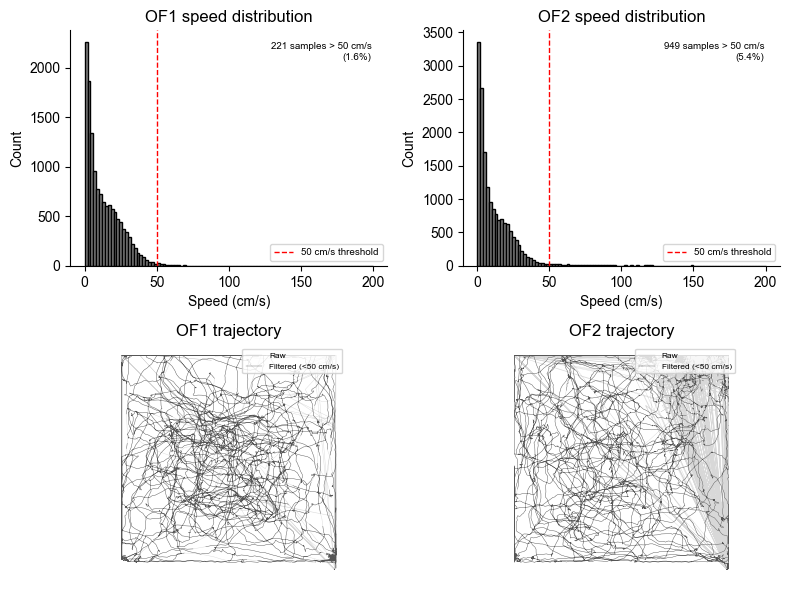

OF1: 949 bad samples (5.4%)


In [7]:
import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
mouse, day = 25, 24

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for col, session in enumerate(['OF1', 'OF2']):
    folder = f'{SOURCE_PATH}M{mouse}/D{day:02}/{session}/'
    beh = nap.load_file(folder + f'sub-{mouse}_day-{day:02}_ses-{session}_beh.nwb')

    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    times = beh['P_x'].times()

    dt = np.diff(times)
    dx = np.diff(px)
    dy = np.diff(py)
    speed = np.sqrt(dx**2 + dy**2) / dt

    # Speed distribution
    ax = axes[0, col]
    ax.hist(speed, bins=100, range=(0, 200), color='grey', edgecolor='black', lw=0.3)
    ax.axvline(50, color='red', ls='--', lw=1, label='50 cm/s threshold')
    ax.set_xlabel('Speed (cm/s)')
    ax.set_ylabel('Count')
    ax.set_title(f'{session} speed distribution')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

    n_above = np.sum(speed > 50)
    ax.annotate(f'{n_above} samples > 50 cm/s\n({100*n_above/len(speed):.1f}%)',
                xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=7)

    # Trajectory: raw vs filtered
    ax = axes[1, col]
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.3, label='Raw')

    # Filter: NaN out positions where speed > 50 cm/s
    speed_full = np.concatenate([[0], speed])
    mask = speed_full < 50
    px_filt = px.copy()
    py_filt = py.copy()
    px_filt[~mask] = np.nan
    py_filt[~mask] = np.nan
    ax.plot(px_filt, py_filt, color='black', lw=0.3, alpha=0.6, label='Filtered (<50 cm/s)')

    ax.set_aspect('equal')
    ax.set_title(f'{session} trajectory')
    ax.legend(fontsize=6, loc='upper right')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"OF1: {np.sum(speed > 50)} bad samples ({100*np.sum(speed > 50)/len(speed):.1f}%)")
